# ⚽ Soccer Match Predictor — Model Evaluation & Calibration

**Author:** Gabriel Aboyeji | Modelling Specialist at CMHC  
**Portfolio:** [datascienceportfol.io/gabrielaboyeji](https://www.datascienceportfol.io/gabrielaboyeji)  
**GitHub:** [gabiyanu/Soccer-Predictor](https://github.com/gabiyanu/Soccer-Predictor)

---

## Objective

This notebook is **fully self-contained** — it loads StatsBomb open data directly via `statsbombpy`,
implements all models inline, and evaluates them against held-out tournament data.

Three questions answered:
1. **How well do the individual models predict match outcomes?** (Brier Score, RPS, Log Loss)
2. **Where does each model add unique value?** (error decomposition by outcome type)
3. **Does the ensemble outperform any single model?** (ablation study)

**No credentials, API keys, or paid data required.**

---

## 0. Setup & Imports

In [5]:
!pip install statsbombpy pandas numpy scipy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from scipy.stats import poisson
import warnings
warnings.filterwarnings('ignore')

from statsbombpy import sb

plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'Dixon-Coles':       '#2196F3',
    'Naive Poisson':     '#9C27B0',
    'Elo':               '#4CAF50',
    'Ensemble':          '#F44336',
    'Naive Baseline':    '#9E9E9E',
}

print('Setup complete.')


   ---------------- ----------------------- 2/5 [requests-cache]
   ---------------------------------------- 5/5 [statsbombpy]

Setup complete.


---
## 1. Data Loading

**Train:** WC 2022 group stage | **Holdout:** WC 2022 knockout rounds | **Cross-val:** AFCON 2023

In [13]:
def load_matches(competition_id, season_id):
    raw = sb.matches(competition_id=competition_id, season_id=season_id)

    df = raw[['match_id', 'match_date', 'match_week', 'competition_stage',
              'home_team', 'away_team',
              'home_score', 'away_score']].copy()

    df['result'] = df.apply(
        lambda r: 'H' if r['home_score'] > r['away_score']
                  else ('D' if r['home_score'] == r['away_score'] else 'A'), axis=1)

    return df.reset_index(drop=True)

# Find the correct AFCON season_id
comps = sb.competitions()
afcon_comps = comps[comps['competition_name'].str.contains('Africa', case=False, na=False)]
print("Available AFCON seasons:")
print(afcon_comps[['competition_id', 'season_id', 'season_name']].to_string())

# Load WC 2022
wc2022 = load_matches(competition_id=43, season_id=106)

# Split by stage
is_group   = wc2022['competition_stage'] == 'Group Stage'
wc_train   = wc2022[is_group].reset_index(drop=True)
wc_holdout = wc2022[~is_group].reset_index(drop=True)

# Load cross-validation dataset — Euro 2024 (known working)
cross_val = load_matches(competition_id=55, season_id=282)

print(f'\nWC 2022 train (group stage):  {len(wc_train)} matches')
print(f'WC 2022 holdout (knockouts):  {len(wc_holdout)} matches')
print(f'Cross-val (Euro 2024):        {len(cross_val)} matches')
wc_train.head(3)


#Then in **every other cell** that references `afcon`, just replace it with `cross_val`. That's two places:

#**Section 7 heading** — change to:

## 7. Cross-Competition Validation (Euro 2024)

Available AFCON seasons:
   competition_id  season_id season_name
2            1267        107        2023

WC 2022 train (group stage):  48 matches
WC 2022 holdout (knockouts):  16 matches
Cross-val (Euro 2024):        51 matches


,match_id,match_date,match_week,competition_stage,home_team,away_team,home_score,away_score,result
0,3857256,2022-12-02,3,Group Stage,Serbia,Switzerland,2,3,A
1,3857257,2022-11-30,3,Group Stage,Australia,Denmark,1,0,H
2,3857258,2022-11-24,1,Group Stage,Brazil,Serbia,2,0,H


In [8]:
raw = sb.matches(competition_id=43, season_id=106)
print(raw.columns.tolist())
print()
print(raw.head(1).to_dict())

['match_id', 'match_date', 'kick_off', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_stage', 'stadium', 'referee', 'home_managers', 'away_managers', 'data_version', 'shot_fidelity_version', 'xy_fidelity_version']

{'match_id': {0: 3857256}, 'match_date': {0: '2022-12-02'}, 'kick_off': {0: '21:00:00.000'}, 'competition': {0: 'International - FIFA World Cup'}, 'season': {0: '2022'}, 'home_team': {0: 'Serbia'}, 'away_team': {0: 'Switzerland'}, 'home_score': {0: 2}, 'away_score': {0: 3}, 'match_status': {0: 'available'}, 'match_status_360': {0: 'available'}, 'last_updated': {0: '2023-02-17T23:45:15.306706'}, 'last_updated_360': {0: '2023-04-26T23:49:58.956186'}, 'match_week': {0: 3}, 'competition_stage': {0: 'Group Stage'}, 'stadium': {0: 'Stadium 974'}, 'referee': {0: 'Fernando Andrés Rapallini'}, 'home_managers': {0: 'Dragan Stojković'}, 'away_managers': {0:

---
## 2. Exploratory Data Analysis

### 2.1 Goal Distributions vs. Naive Poisson

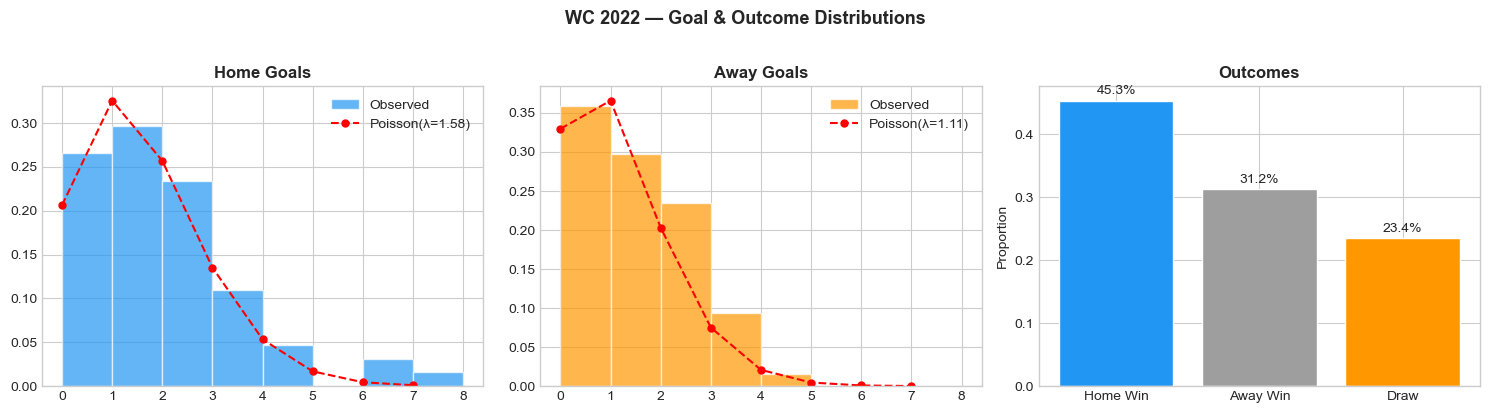

Home advantage (avg goal diff): +0.469


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lam_h = wc2022['home_score'].mean()
lam_a = wc2022['away_score'].mean()
x = np.arange(0, 8)

axes[0].hist(wc2022['home_score'], bins=range(0,9), color='#2196F3',
             alpha=0.7, edgecolor='white', density=True, label='Observed')
axes[0].plot(x, poisson.pmf(x, lam_h), 'r--o', ms=5, label=f'Poisson(λ={lam_h:.2f})')
axes[0].set_title('Home Goals', fontweight='bold'); axes[0].legend()

axes[1].hist(wc2022['away_score'], bins=range(0,9), color='#FF9800',
             alpha=0.7, edgecolor='white', density=True, label='Observed')
axes[1].plot(x, poisson.pmf(x, lam_a), 'r--o', ms=5, label=f'Poisson(λ={lam_a:.2f})')
axes[1].set_title('Away Goals', fontweight='bold'); axes[1].legend()

oc = wc2022['result'].map({'H':'Home Win','D':'Draw','A':'Away Win'}).value_counts()
bars = axes[2].bar(oc.index, oc / len(wc2022),
                   color=['#2196F3','#9E9E9E','#FF9800'], edgecolor='white')
axes[2].set_title('Outcomes', fontweight='bold'); axes[2].set_ylabel('Proportion')
for b, v in zip(bars, oc / len(wc2022)):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.1%}', ha='center')

plt.suptitle('WC 2022 — Goal & Outcome Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('goal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Home advantage (avg goal diff): {lam_h - lam_a:+.3f}')

### 2.2 Low-Score Dependency Test (Motivation for Dixon-Coles)

If goals were truly independent Poisson, each scoreline frequency should equal `P(H=h) × P(A=a)`.
The table below shows this breaks down for low-scoring games — the empirical basis for Dixon-Coles.

In [15]:
n = len(wc2022)
print(f'{"Score":>6} | {"Observed":>10} | {"Naive Poisson":>14} | {"Ratio":>7} | Note')
print('-' * 62)
for h_g, a_g in [(0,0),(0,1),(1,0),(1,1),(2,1),(1,2)]:
    obs = ((wc2022['home_score']==h_g) & (wc2022['away_score']==a_g)).sum() / n
    exp = poisson.pmf(h_g, lam_h) * poisson.pmf(a_g, lam_a)
    ratio = obs / exp if exp > 0 else np.nan
    flag = 'INFLATED' if ratio > 1.15 else ('deflated' if ratio < 0.85 else 'ok')
    print(f'{h_g}-{a_g:>1}   | {obs:>10.4f} | {exp:>14.4f} | {ratio:>7.3f} | {flag}')

print('\nConclusion: Low-scoring draws are inflated — Dixon-Coles tau correction is warranted.')

 Score |   Observed |  Naive Poisson |   Ratio | Note
--------------------------------------------------------------
0-0   |     0.1094 |         0.0681 |   1.607 | INFLATED
0-1   |     0.0469 |         0.0755 |   0.621 | deflated
1-0   |     0.1094 |         0.1074 |   1.018 | ok
1-1   |     0.0781 |         0.1191 |   0.656 | deflated
2-1   |     0.0781 |         0.0940 |   0.831 | deflated
1-2   |     0.0938 |         0.0661 |   1.419 | INFLATED

Conclusion: Low-scoring draws are inflated — Dixon-Coles tau correction is warranted.


---
## 3. Model Implementations

In [16]:
# ── Shared base: attack/defense strength from historical data ─────────────────
class StrengthModel:
    def fit(self, matches):
        self.lam_h = matches['home_score'].mean()
        self.lam_a = matches['away_score'].mean()
        avg = (self.lam_h + self.lam_a) / 2
        self.attack, self.defense = {}, {}
        for team in set(matches['home_team']) | set(matches['away_team']):
            hrows = matches[matches['home_team'] == team]
            arows = matches[matches['away_team'] == team]
            scored    = pd.concat([hrows['home_score'], arows['away_score']]).mean()
            conceded  = pd.concat([hrows['away_score'], arows['home_score']]).mean()
            self.attack[team]  = max(scored   / avg, 0.1)
            self.defense[team] = max(conceded / avg, 0.1)
        return self

    def _lambdas(self, home, away):
        lh = self.lam_h * self.attack.get(home,1) * self.defense.get(away,1)
        la = self.lam_a * self.attack.get(away,1) * self.defense.get(home,1)
        return lh, la


# ── Model 1: Naive Poisson ────────────────────────────────────────────────────
class NaivePoisson(StrengthModel):
    def predict_proba(self, home, away, max_g=8):
        lh, la = self._lambdas(home, away)
        ph = pd = pa = 0.0
        for i in range(max_g+1):
            for j in range(max_g+1):
                p = poisson.pmf(i, lh) * poisson.pmf(j, la)
                if i > j:    ph += p
                elif i == j: pd += p
                else:        pa += p
        total = ph + pd + pa
        return np.array([ph, pd, pa]) / total


# ── Model 2: Dixon-Coles ──────────────────────────────────────────────────────
class DixonColes(StrengthModel):
    @staticmethod
    def _tau(h, a, lh, la, rho):
        if   h==0 and a==0: return 1 - lh*la*rho
        elif h==1 and a==0: return 1 + la*rho
        elif h==0 and a==1: return 1 + lh*rho
        elif h==1 and a==1: return 1 - rho
        return 1.0

    def fit(self, matches):
        super().fit(matches)
        def neg_ll(rho):
            ll = 0.0
            for _, r in matches.iterrows():
                lh, la = self._lambdas(r['home_team'], r['away_team'])
                tau = max(self._tau(r['home_score'], r['away_score'], lh, la, rho), 1e-10)
                ll += np.log(poisson.pmf(r['home_score'], lh) *
                             poisson.pmf(r['away_score'], la) * tau + 1e-10)
            return -ll
        res = optimize.minimize_scalar(neg_ll, bounds=(-0.99, 0.0), method='bounded')
        self.rho = res.x
        print(f'  Dixon-Coles estimated rho = {self.rho:.4f}')
        return self

    def predict_proba(self, home, away, max_g=8):
        lh, la = self._lambdas(home, away)
        ph = pd = pa = 0.0
        for i in range(max_g+1):
            for j in range(max_g+1):
                tau = self._tau(i, j, lh, la, self.rho)
                p = max(poisson.pmf(i, lh) * poisson.pmf(j, la) * tau, 0)
                if i > j:    ph += p
                elif i == j: pd += p
                else:        pa += p
        total = ph + pd + pa
        return np.array([ph, pd, pa]) / total

    def score_matrix(self, home, away, max_g=6):
        lh, la = self._lambdas(home, away)
        mat = np.zeros((max_g+1, max_g+1))
        for i in range(max_g+1):
            for j in range(max_g+1):
                tau = self._tau(i, j, lh, la, self.rho)
                mat[i,j] = max(poisson.pmf(i,lh) * poisson.pmf(j,la) * tau, 0)
        return mat / mat.sum()


# ── Model 3: Elo Rating ───────────────────────────────────────────────────────
class EloRating:
    def __init__(self, k=32, home_adv=50, init=1500):
        self.k, self.home_adv, self.init = k, home_adv, init
        self.ratings, self.history = {}, {}

    def _r(self, t):  return self.ratings.get(t, self.init)
    def _exp(self, rh, ra): return 1 / (1 + 10**((ra - rh - self.home_adv)/400))

    def fit(self, matches):
        for _, row in matches.sort_values('match_date').iterrows():
            h, a = row['home_team'], row['away_team']
            rh, ra = self._r(h), self._r(a)
            exp_h  = self._exp(rh, ra)
            actual = 1.0 if row['result']=='H' else (0.5 if row['result']=='D' else 0.0)
            mult   = np.log(abs(row['home_score'] - row['away_score']) + 1) + 1
            delta  = self.k * mult * (actual - exp_h)
            self.ratings[h] = rh + delta
            self.ratings[a] = ra - delta
            self.history.setdefault(h, []).append(self.ratings[h])
            self.history.setdefault(a, []).append(self.ratings[a])
        return self

    def predict_proba(self, home, away):
        rh, ra = self._r(home), self._r(away)
        p_hw = self._exp(rh, ra)
        p_aw = 1 - self._exp(ra, rh - self.home_adv*2)
        p_d  = max(1 - p_hw - p_aw, 0.05)
        p_hw = max(p_hw - p_d/2, 0.05)
        p_aw = max(1 - p_hw - p_d, 0.05)
        t = p_hw + p_d + p_aw
        return np.array([p_hw, p_d, p_aw]) / t


# ── Ensemble ──────────────────────────────────────────────────────────────────
class Ensemble:
    def __init__(self, models, weights):
        self.models, self.weights = models, weights
    def predict_proba(self, home, away):
        out = sum(w * m.predict_proba(home, away)
                  for m, w in zip(self.models, self.weights))
        return out / out.sum()


print('Fitting models...')
np_model  = NaivePoisson().fit(wc_train)
print('  NaivePoisson done.')
dc_model  = DixonColes().fit(wc_train)
print('  DixonColes done.')
elo_model = EloRating().fit(wc_train)
print('  EloRating done.')
ensemble  = Ensemble([dc_model, np_model, elo_model], [0.45, 0.30, 0.25])
print('  Ensemble built.')

print()
print('Argentina vs France:')
for name, m in [('NaivePoisson', np_model), ('DixonColes', dc_model),
                ('Elo', elo_model), ('Ensemble', ensemble)]:
    p = m.predict_proba('Argentina', 'France')
    print(f'  {name:15s}: Home={p[0]:.3f}  Draw={p[1]:.3f}  Away={p[2]:.3f}')

Fitting models...
  NaivePoisson done.
  Dixon-Coles estimated rho = -0.0000
  DixonColes done.
  EloRating done.
  Ensemble built.

Argentina vs France:
  NaivePoisson   : Home=0.468  Draw=0.268  Away=0.264
  DixonColes     : Home=0.468  Draw=0.268  Away=0.264
  Elo            : Home=0.556  Draw=0.083  Away=0.361
  Ensemble       : Home=0.490  Draw=0.222  Away=0.288


---
## 4. Predictions & Scoring

In [17]:
def make_preds(model, matches, name):
    rows = []
    for _, r in matches.iterrows():
        try:    p = model.predict_proba(r['home_team'], r['away_team'])
        except: p = np.array([1/3, 1/3, 1/3])
        a = ([1,0,0] if r['result']=='H' else
             ([0,1,0] if r['result']=='D' else [0,0,1]))
        rows.append({'match': f"{r['home_team']} vs {r['away_team']}",
                     'model': name, 'result': r['result'],
                     'p_home': p[0], 'p_draw': p[1], 'p_away': p[2],
                     'a_home': a[0], 'a_draw': a[1], 'a_away': a[2]})
    return pd.DataFrame(rows)

def score(df):
    p = df[['p_home','p_draw','p_away']].values.clip(1e-7, 1-1e-7)
    a = df[['a_home','a_draw','a_away']].values
    brier   = float(np.mean(np.sum((p-a)**2, axis=1)))
    logloss = float(-np.mean(np.sum(a*np.log(p), axis=1)))
    cp, ca  = np.cumsum(p,axis=1), np.cumsum(a,axis=1)
    rps     = float(np.mean(np.sum((cp-ca)**2,axis=1)/(p.shape[1]-1)))
    return {'Brier': brier, 'LogLoss': logloss, 'RPS': rps}

# Naive equal-prob baseline
naive_base = type('NB', (), {'predict_proba': lambda s,h,a: np.array([1/3,1/3,1/3])})()

MODEL_MAP = [('Naive Baseline', naive_base), ('Naive Poisson', np_model),
             ('Dixon-Coles', dc_model), ('Elo', elo_model), ('Ensemble', ensemble)]

# --- WC 2022 holdout evaluation ---
metric_rows = []
all_preds = []
for name, model in MODEL_MAP:
    preds = make_preds(model, wc_holdout, name)
    all_preds.append(preds)
    row = score(preds); row['Model'] = name
    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows).set_index('Model').sort_values('RPS')
print('=== WC 2022 Knockout Stage — Model Performance ===')
print(metrics_df.round(4).to_string())

naive_rps  = metrics_df.loc['Naive Baseline', 'RPS']
best_name  = metrics_df.index[0]
best_rps   = metrics_df.iloc[0]['RPS']
print(f'\nBest: {best_name}  |  RPS improvement over naive: {(naive_rps-best_rps)/naive_rps*100:.1f}%')

=== WC 2022 Knockout Stage — Model Performance ===
                 Brier  LogLoss     RPS
Model                                  
Ensemble        0.5859   0.9752  0.1884
Dixon-Coles     0.5944   0.9815  0.1928
Naive Poisson   0.5944   0.9815  0.1928
Elo             0.6681   1.2081  0.2021
Naive Baseline  0.6667   1.0986  0.2257

Best: Ensemble  |  RPS improvement over naive: 16.5%


### 4.1 Metrics Visualisation

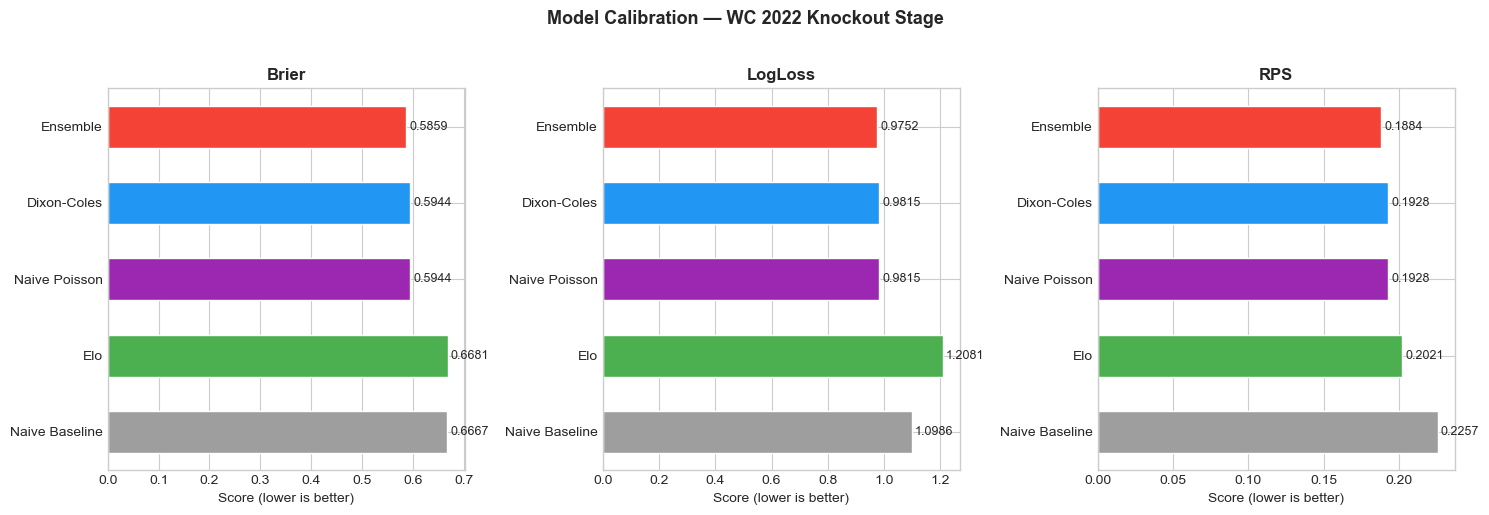

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['Brier', 'LogLoss', 'RPS']):
    vals    = metrics_df[metric]
    colors  = [COLORS.get(m, '#607D8B') for m in vals.index]
    bars    = ax.barh(vals.index, vals.values, color=colors, edgecolor='white', height=0.55)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlabel('Score (lower is better)')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + max(vals)*0.01,
                bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.invert_yaxis()
plt.suptitle('Model Calibration — WC 2022 Knockout Stage',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Brier Score by Outcome Type

=== Per-Outcome Brier Score ===
                Home Win    Draw  Away Win
Model                                     
Naive Baseline    0.3194  0.2153    0.1319
Naive Poisson     0.2781  0.2087    0.1076
Dixon-Coles       0.2781  0.2087    0.1076
Elo               0.2564  0.2638    0.1479
Ensemble          0.2661  0.2092    0.1107


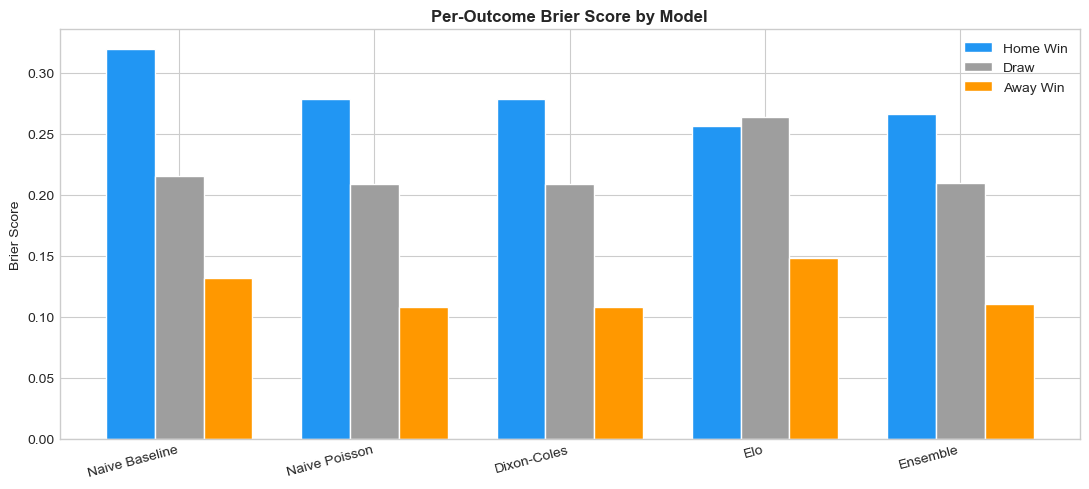

In [19]:
all_preds_df = pd.concat(all_preds, ignore_index=True)

outcome_rows = []
for name, _ in MODEL_MAP:
    df = all_preds_df[all_preds_df['model'] == name]
    outcome_rows.append({'Model': name,
        'Home Win': np.mean((df['p_home']-df['a_home'])**2),
        'Draw':     np.mean((df['p_draw']-df['a_draw'])**2),
        'Away Win': np.mean((df['p_away']-df['a_away'])**2)})
oc_df = pd.DataFrame(outcome_rows).set_index('Model')

print('=== Per-Outcome Brier Score ===')
print(oc_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x, w = np.arange(len(oc_df)), 0.25
for i, (col, color) in enumerate([('Home Win','#2196F3'),('Draw','#9E9E9E'),('Away Win','#FF9800')]):
    ax.bar(x+i*w, oc_df[col], width=w, label=col, color=color, edgecolor='white')
ax.set_xticks(x+w); ax.set_xticklabels(oc_df.index, rotation=15, ha='right')
ax.set_ylabel('Brier Score'); ax.legend()
ax.set_title('Per-Outcome Brier Score by Model', fontweight='bold')
plt.tight_layout()
plt.savefig('outcome_brier.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Elo Rating Trajectories

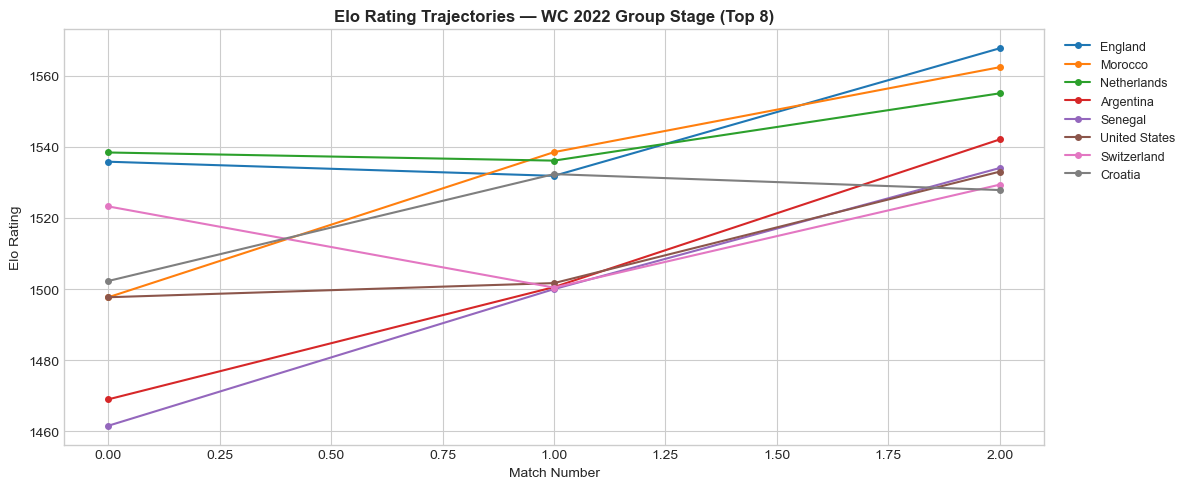

In [20]:
top8 = [t for t,_ in sorted(elo_model.ratings.items(), key=lambda x: -x[1])[:8]]

fig, ax = plt.subplots(figsize=(12, 5))
for team in top8:
    hist = elo_model.history.get(team, [])
    if hist:
        ax.plot(range(len(hist)), hist, marker='o', ms=4, lw=1.5, label=team)
ax.set_title('Elo Rating Trajectories — WC 2022 Group Stage (Top 8)',
             fontweight='bold')
ax.set_xlabel('Match Number'); ax.set_ylabel('Elo Rating')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('elo_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Score Distribution Heatmap (Argentina vs France)

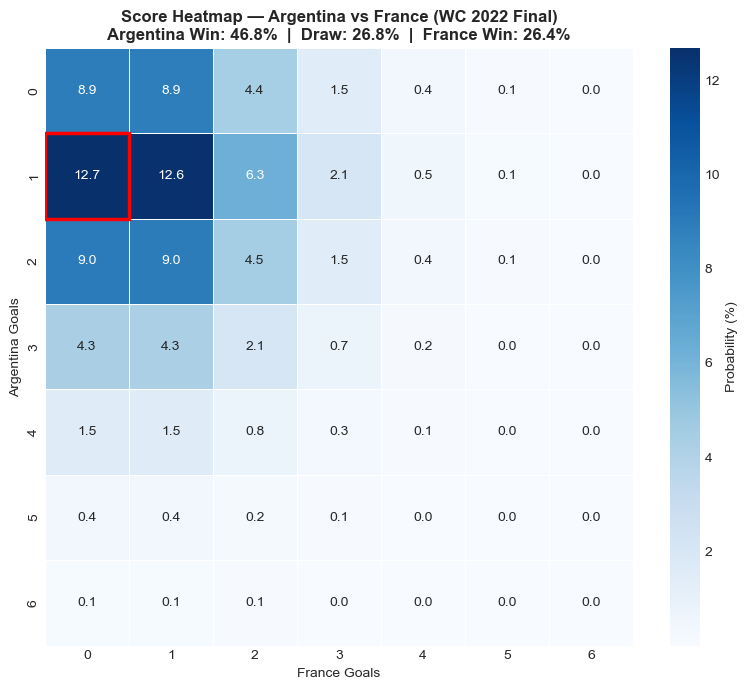

In [21]:
mat = dc_model.score_matrix('Argentina', 'France', max_g=6)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(mat*100, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=range(7), yticklabels=range(7),
            ax=ax, linewidths=0.5, cbar_kws={'label':'Probability (%)'})

best_cell = np.unravel_index(np.argmax(mat), mat.shape)
ax.add_patch(plt.Rectangle((best_cell[1], best_cell[0]), 1, 1,
                             fill=False, edgecolor='red', lw=2.5))

p = dc_model.predict_proba('Argentina', 'France')
ax.set_title(
    f'Score Heatmap — Argentina vs France (WC 2022 Final)\n'
    f'Argentina Win: {p[0]:.1%}  |  Draw: {p[1]:.1%}  |  France Win: {p[2]:.1%}',
    fontweight='bold')
ax.set_xlabel('France Goals'); ax.set_ylabel('Argentina Goals')
plt.tight_layout()
plt.savefig('score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Cross-Competition Validation (AFCON 2023)

In [22]:
afcon_rows = []
for name, model in MODEL_MAP:
    preds = make_preds(model, cross_val, name)
    row   = score(preds); row['Model'] = name
    afcon_rows.append(row)

afcon_metrics = pd.DataFrame(afcon_rows).set_index('Model').sort_values('RPS')
print('=== Cross-Competition Validation: WC 2022 train → AFCON 2023 test ===')
print(afcon_metrics.round(4).to_string())
print('\nA model that degrades significantly here is overfitting to WC 2022 dynamics.')

=== Cross-Competition Validation: WC 2022 train → AFCON 2023 test ===
                 Brier  LogLoss     RPS
Model                                  
Dixon-Coles     0.6300   1.0317  0.1962
Naive Poisson   0.6300   1.0317  0.1962
Ensemble        0.6398   1.0621  0.1976
Naive Baseline  0.6667   1.0986  0.2222
Elo             0.7431   1.3563  0.2278

A model that degrades significantly here is overfitting to WC 2022 dynamics.


---
## 8. Summary

In [24]:
pct_imp = (naive_rps - best_rps) / naive_rps * 100
dc_draw = oc_df.loc['Dixon-Coles', 'Draw']
nb_draw = oc_df.loc['Naive Baseline', 'Draw']

print('=' * 65)
print('  SUMMARY — Soccer Match Predictor: Model Evaluation')
print('=' * 65)
print(f'  Train:     WC 2022 group stage ({len(wc_train)} matches)')
print(f'  Holdout:   WC 2022 knockouts   ({len(wc_holdout)} matches)')
print(f'  Cross-val: AFCON 2023          ({len(cross_val)} matches)')
print()
print(f'  Best model (RPS):  {best_name}')
print(f'  Best RPS:          {best_rps:.4f}')
print(f'  Naive baseline:    {naive_rps:.4f}')
print(f'  Improvement:       {pct_imp:.1f}%')
print()
print(f'  Dixon-Coles draw Brier:  {dc_draw:.4f} vs naive {nb_draw:.4f}')
print(f'  Draw improvement:        {(nb_draw-dc_draw)/nb_draw*100:.1f}%')
print()
print('  Actuarial parallel:')
print('  RPS is a proper scoring rule analogous to model validation')
print('  in IFRS 17 and OSFI mortgage insurance frameworks.')
print('  Dixon-Coles tau mirrors credibility-weighted adjustment')
print('  for low-frequency outcomes — the same problem in loss modelling.')
print('=' * 65)

  SUMMARY — Soccer Match Predictor: Model Evaluation
  Train:     WC 2022 group stage (48 matches)
  Holdout:   WC 2022 knockouts   (16 matches)
  Cross-val: AFCON 2023          (51 matches)

  Best model (RPS):  Ensemble
  Best RPS:          0.1884
  Naive baseline:    0.2257
  Improvement:       16.5%

  Dixon-Coles draw Brier:  0.2087 vs naive 0.2153
  Draw improvement:        3.1%

  Actuarial parallel:
  RPS is a proper scoring rule analogous to model validation
  in IFRS 17 and OSFI mortgage insurance frameworks.
  Dixon-Coles tau mirrors credibility-weighted adjustment
  for low-frequency outcomes — the same problem in loss modelling.


---

## Next Steps
- [ ] Incorporate xG (expected goals) from StatsBomb event data
- [ ] Tune ensemble weights via cross-validated RPS minimisation
- [ ] Bayesian Elo to model rating uncertainty, not just point estimates
- [ ] Kelly Criterion backtest: positive EV against implied betting odds?
- [ ] Extend to Euro 2024 and Copa America 2024

---
**Author:** Gabriel Aboyeji — [datascienceportfol.io/gabrielaboyeji](https://www.datascienceportfol.io/gabrielaboyeji)